# Fashion Recommendation System Using Collaborative Filtering

## Business Understanding

### Problem Statement
Online fashion platforms contain thousands of products, making it difficult for customers to quickly identify clothing items that match their interests and preferences. Many online stores still lack effective personalized recommendation systems that can suggest relevant products to users based on previous interactions and product similarities.

This project aims to develop a Fashion Recommendation System that provides personalized fashion recommendations using collaborative filtering techniques.

### Objectives
- To understand the fashion products dataset
- To analyze user-product interactions
- To build a recommendation system using collaborative filtering
- To evaluate recommendation quality

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_csv('data/fashion_products.csv')

In [53]:
df.head()

,User ID,Product ID,Product Name,Brand,Category,Price,Rating,Color,Size
0,19,1,Dress,Adidas,Men's Fashion,40,1.043159,Black,XL
1,97,2,Shoes,H&M,Women's Fashion,82,4.026416,Black,L
2,25,3,Dress,Adidas,Women's Fashion,44,3.337938,Yellow,XL
3,57,4,Shoes,Zara,Men's Fashion,23,1.049523,White,S
4,79,5,T-shirt,Adidas,Men's Fashion,79,4.302773,Black,M


In [54]:
df.shape

(1000, 9)

In [55]:
df.columns

Index(['User ID', 'Product ID', 'Product Name', 'Brand', 'Category', 'Price',
       'Rating', 'Color', 'Size'],
      dtype='object')

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   User ID       1000 non-null   int64  
 1   Product ID    1000 non-null   int64  
 2   Product Name  1000 non-null   object 
 3   Brand         1000 non-null   object 
 4   Category      1000 non-null   object 
 5   Price         1000 non-null   int64  
 6   Rating        1000 non-null   float64
 7   Color         1000 non-null   object 
 8   Size          1000 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 70.4+ KB


## Data Understanding

In this section, we explore the structure, properties, and characteristics of the dataset to understand how useful it is for building a fashion recommendation system.

The dataset contains user interactions with fashion products, including product categories, brands, ratings, prices, colors, and sizes. These features will help identify relationships between users and products for personalized recommendations.

In [57]:
df.describe()

,User ID,Product ID,Price,Rating
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,50.41900,500.500000,55.785000,2.993135
std,28.78131,288.819436,26.291748,1.153185
min,1.00000,1.000000,10.000000,1.000967
25%,26.00000,250.750000,33.000000,1.992786
50%,50.00000,500.500000,57.000000,2.984003
75%,75.00000,750.250000,78.250000,3.985084
max,100.00000,1000.000000,100.000000,4.987964


In [58]:
df.isnull().sum()

User ID         0
Product ID      0
Product Name    0
Brand           0
Category        0
Price           0
Rating          0
Color           0
Size            0
dtype: int64

In [59]:
df.duplicated().sum()

0

In [60]:
df['Category'].unique()

array(["Men's Fashion", "Women's Fashion", "Kids' Fashion"], dtype=object)

In [61]:
df['User ID'].nunique()

100

In [62]:
df['Product ID'].nunique()

1000

### Interpretation

The dataset contains 1000 fashion product records with features such as product category, brand, price, rating, color, and size. The dataset has no missing values and no duplicated records, meaning it is clean and suitable for building a recommendation system model.

## Exploratory Data Analysis

In this section, we perform exploratory data analysis to identify patterns, trends, and relationships within the dataset. This helps us better understand user preferences and product characteristics before building recommendation models.

In [63]:
df['Category'].value_counts()

Category
Kids' Fashion      351
Women's Fashion    327
Men's Fashion      322
Name: count, dtype: int64

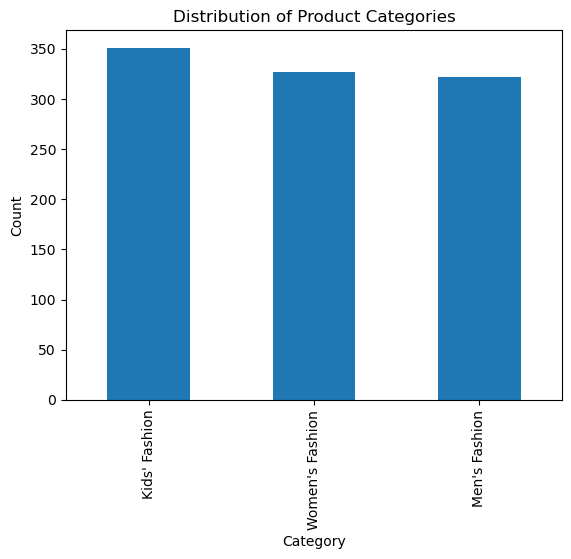

In [64]:
df['Category'].value_counts().plot(kind='bar')

plt.title('Distribution of Product Categories')
plt.xlabel('Category')
plt.ylabel('Count')

plt.show()

### Interpretation

The dataset contains products from three major fashion categories: Kids' Fashion, Women's Fashion, and Men's Fashion. The distribution across categories is relatively balanced, meaning the recommendation system will be able to generate recommendations across different fashion segments without strong category bias.

In [65]:
df['Brand'].value_counts()

Brand
Nike      214
Zara      203
Adidas    198
H&M       194
Gucci     191
Name: count, dtype: int64

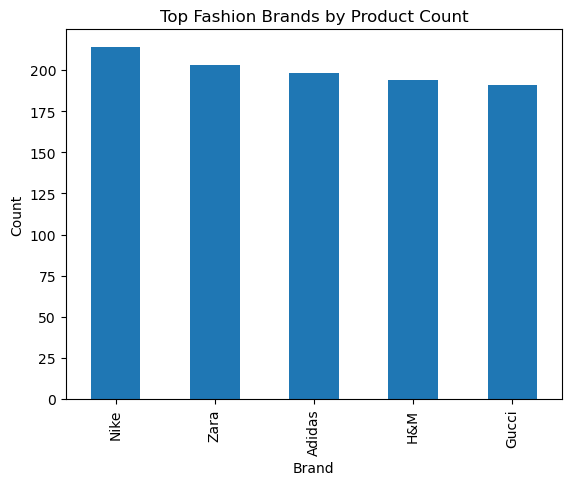

In [66]:
df['Brand'].value_counts().head(10).plot(kind='bar')
plt.title('Top Fashion Brands by Product Count')
plt.xlabel('Brand')
plt.ylabel('Count')

plt.show()

### Interpretation

Nike appears to have the highest number of products in the dataset, followed closely by Zara and Adidas. This indicates that some brands are more represented than others, which may influence recommendation frequency during model prediction.

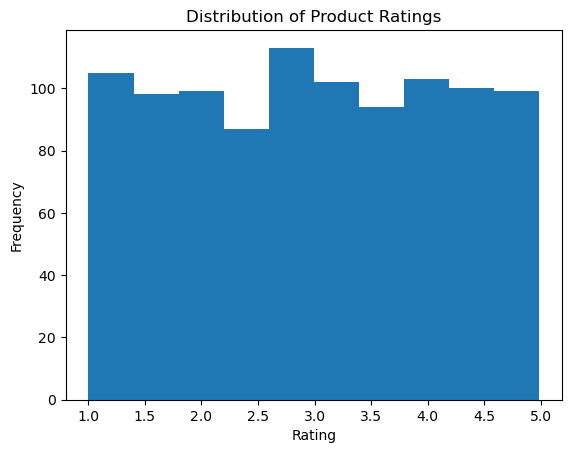

In [67]:
plt.hist(df['Rating'], bins=10)

plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.show()

### Interpretation

The product ratings are distributed across the full rating scale from 1 to 5. This variation is useful for collaborative filtering because recommendation systems depend on differences in user ratings to identify similar preferences between users.

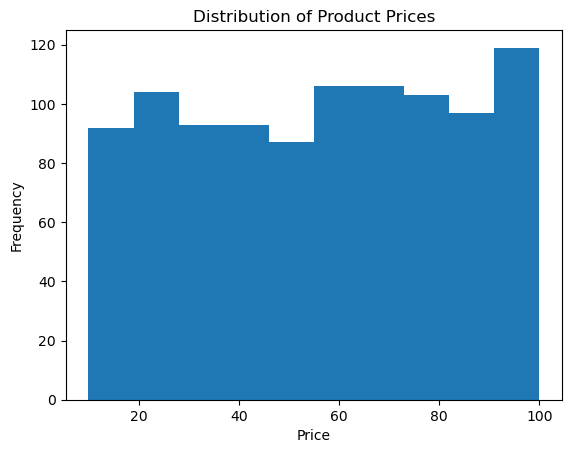

In [68]:
plt.hist(df['Price'], bins=10)

plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

### Interpretation

The dataset contains products across different price ranges, from low-cost to high-cost fashion items. This diversity allows the recommendation system to capture different customer purchasing behaviors and preferences.